In [1]:
# ============================================================
# CSI_6_ARI CW2 - Practical Implementation
# Student ID: 4200638
# RI: T3-M4-S1
# Models: Extra Trees, MLP, Gradient Boosting
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    accuracy_score
)

from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
FP_COST = 10
FN_COST = 500

train_path = "SMI_Train_4200638 (1).csv"
test_path = "SMI_Test_800 (1).csv"
operational_path = "SMI_Operational_200 (1).csv"

# Load data. Treat 'na' strings as missing values.
train_df = pd.read_csv(train_path, na_values=["na", "NA", "NaN", "nan", "", " "])
test_df = pd.read_csv(test_path, na_values=["na", "NA", "NaN", "nan", "", " "])
operational_df = pd.read_csv(operational_path, na_values=["na", "NA", "NaN", "nan", "", " "])

print("Files loaded successfully.")
print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Operational shape:", operational_df.shape)

print("\nTraining columns preview:")
print(train_df.columns[:10].tolist())

print("\nTraining class distribution:")
print(train_df["class"].value_counts())

Files loaded successfully.
Training shape: (8000, 171)
Test shape: (800, 171)
Operational shape: (200, 170)

Training columns preview:
['class', 'Sensor_001', 'Sensor_002', 'Sensor_003', 'Sensor_004', 'Sensor_005', 'Sensor_006', 'Sensor_007', 'Sensor_008', 'Sensor_009']

Training class distribution:
class
neg    7867
pos     133
Name: count, dtype: int64


In [2]:
# ============================================================
# Cell 2: Exploratory Data Analysis (EDA)
# Dataset structure, class imbalance, and missingness evidence
# ============================================================

def dataset_overview(df, name, has_label=True):
    rows, cols = df.shape
    sensor_cols = [c for c in df.columns if c.startswith("Sensor_")]

    print(f"\n{name} DATASET OVERVIEW")
    print("-" * 60)
    print(f"Rows: {rows}")
    print(f"Columns: {cols}")
    print(f"Sensor feature columns: {len(sensor_cols)}")

    if has_label:
        print(f"Label column present: {'class' in df.columns}")
        print("\nClass distribution:")
        counts = df["class"].value_counts()
        percents = df["class"].value_counts(normalize=True) * 100
        class_summary = pd.DataFrame({
            "count": counts,
            "percentage": percents.round(2)
        })
        display(class_summary)

    total_cells = df[sensor_cols].shape[0] * df[sensor_cols].shape[1]
    missing_cells = df[sensor_cols].isna().sum().sum()
    missing_percent = (missing_cells / total_cells) * 100
    rows_with_missing = df[sensor_cols].isna().any(axis=1).sum()
    rows_with_missing_percent = (rows_with_missing / rows) * 100

    print("\nMissingness summary:")
    print(f"Total sensor cells: {total_cells}")
    print(f"Missing sensor cells: {missing_cells}")
    print(f"Overall missingness: {missing_percent:.2f}%")
    print(f"Rows with at least one missing sensor value: {rows_with_missing} ({rows_with_missing_percent:.2f}%)")

    missing_by_sensor = df[sensor_cols].isna().sum().sort_values(ascending=False)
    missing_table = pd.DataFrame({
        "missing_count": missing_by_sensor,
        "missing_percentage": (missing_by_sensor / rows * 100).round(2)
    })

    print("\nTop 10 sensors with most missing values:")
    display(missing_table.head(10))

    return {
        "name": name,
        "rows": rows,
        "columns": cols,
        "sensor_columns": len(sensor_cols),
        "missing_cells": missing_cells,
        "missing_percent": missing_percent,
        "rows_with_missing": rows_with_missing,
        "rows_with_missing_percent": rows_with_missing_percent,
        "missing_table": missing_table
    }

train_overview = dataset_overview(train_df, "TRAIN", has_label=True)
test_overview = dataset_overview(test_df, "TEST", has_label=True)
operational_overview = dataset_overview(operational_df, "OPERATIONAL", has_label=False)

# Combined summary table for report evidence
eda_summary = pd.DataFrame([
    {
        "dataset": train_overview["name"],
        "rows": train_overview["rows"],
        "columns": train_overview["columns"],
        "sensor_features": train_overview["sensor_columns"],
        "missing_cells": train_overview["missing_cells"],
        "missing_percent": round(train_overview["missing_percent"], 2),
        "rows_with_missing_percent": round(train_overview["rows_with_missing_percent"], 2)
    },
    {
        "dataset": test_overview["name"],
        "rows": test_overview["rows"],
        "columns": test_overview["columns"],
        "sensor_features": test_overview["sensor_columns"],
        "missing_cells": test_overview["missing_cells"],
        "missing_percent": round(test_overview["missing_percent"], 2),
        "rows_with_missing_percent": round(test_overview["rows_with_missing_percent"], 2)
    },
    {
        "dataset": operational_overview["name"],
        "rows": operational_overview["rows"],
        "columns": operational_overview["columns"],
        "sensor_features": operational_overview["sensor_columns"],
        "missing_cells": operational_overview["missing_cells"],
        "missing_percent": round(operational_overview["missing_percent"], 2),
        "rows_with_missing_percent": round(operational_overview["rows_with_missing_percent"], 2)
    }
])

print("\nCombined EDA summary table:")
display(eda_summary)

# Save EDA summary as CSV for evidence
eda_summary.to_csv("eda_summary_4200638.csv", index=False)
print("\nSaved: eda_summary_4200638.csv")


TRAIN DATASET OVERVIEW
------------------------------------------------------------
Rows: 8000
Columns: 171
Sensor feature columns: 170
Label column present: True

Class distribution:


,count,percentage
class,,
neg,7867,98.34
pos,133,1.66



Missingness summary:
Total sensor cells: 1360000
Missing sensor cells: 113963
Overall missingness: 8.38%
Rows with at least one missing sensor value: 7924 (99.05%)

Top 10 sensors with most missing values:


,missing_count,missing_percentage
Sensor_079,6565,82.06
Sensor_078,6493,81.16
Sensor_077,6366,79.57
Sensor_113,6185,77.31
Sensor_002,6185,77.31
Sensor_076,6154,76.92
Sensor_075,5866,73.32
Sensor_074,5255,65.69
Sensor_073,3617,45.21
Sensor_072,3074,38.42



TEST DATASET OVERVIEW
------------------------------------------------------------
Rows: 800
Columns: 171
Sensor feature columns: 170
Label column present: True

Class distribution:


...


OPERATIONAL DATASET OVERVIEW
------------------------------------------------------------
Rows: 200
Columns: 170
Sensor feature columns: 170

Missingness summary:
Total sensor cells: 34000
Missing sensor cells: 2519
Overall missingness: 7.41%
Rows with at least one missing sensor value: 198 (99.00%)

Top 10 sensors with most missing values:


,missing_count,missing_percentage
Sensor_078,158,79.0
Sensor_079,158,79.0
Sensor_077,154,77.0
Sensor_113,150,75.0
Sensor_002,150,75.0
Sensor_076,147,73.5
Sensor_075,137,68.5
Sensor_074,129,64.5
Sensor_073,95,47.5
Sensor_072,84,42.0



Combined EDA summary table:


,dataset,rows,columns,sensor_features,missing_cells,missing_percent,rows_with_missing_percent
0,TRAIN,8000,171,170,113963,8.38,99.05
1,TEST,800,171,170,14207,10.45,97.62
2,OPERATIONAL,200,170,170,2519,7.41,99.00



Saved: eda_summary_4200638.csv


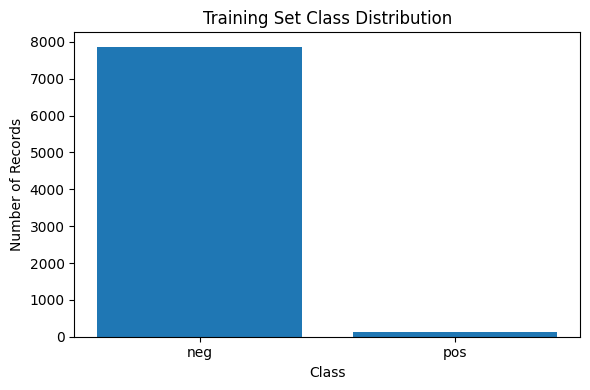

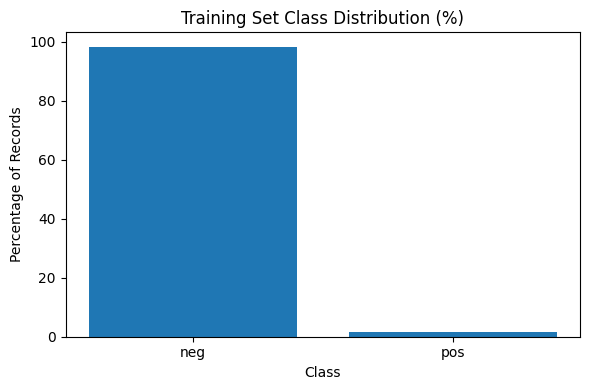

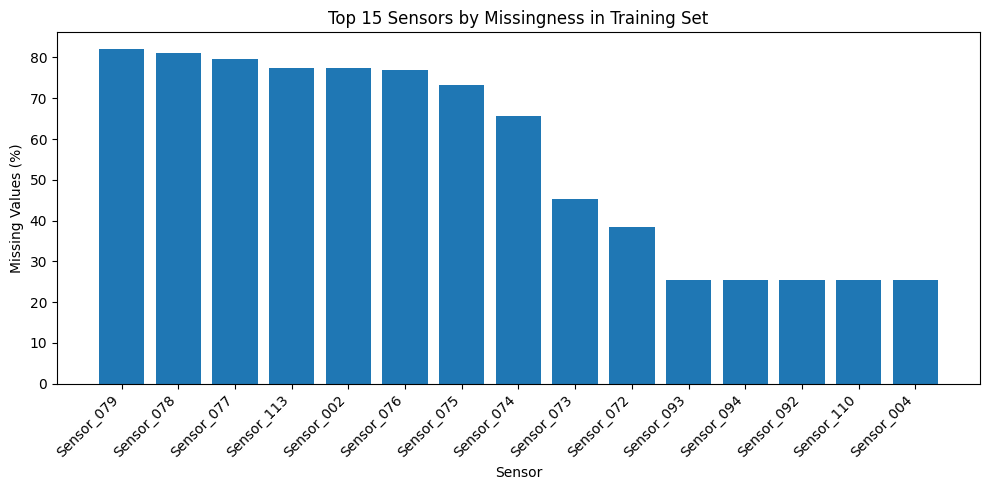

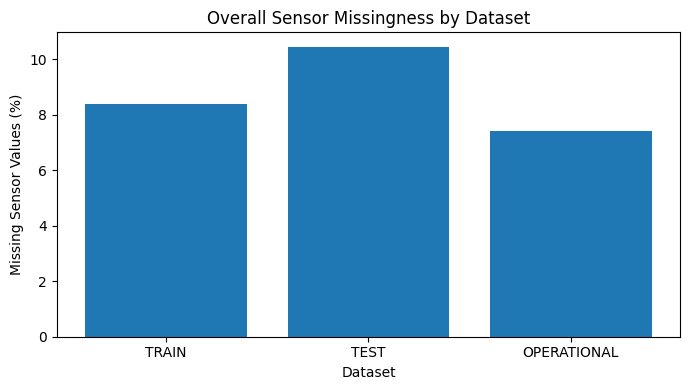

Saved figures:
fig_class_distribution_train.png
fig_class_distribution_percentage_train.png
fig_top15_missing_sensors_train.png
fig_missingness_by_dataset.png


In [3]:
# ============================================================
# Cell 3: EDA visual evidence
# Class imbalance and missingness graphs
# ============================================================

# 1. Training class imbalance bar chart
class_counts = train_df["class"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.savefig("fig_class_distribution_train.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Training class imbalance percentage chart
class_percentages = train_df["class"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
plt.bar(class_percentages.index, class_percentages.values)
plt.title("Training Set Class Distribution (%)")
plt.xlabel("Class")
plt.ylabel("Percentage of Records")
plt.tight_layout()
plt.savefig("fig_class_distribution_percentage_train.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Top 15 missing sensors in training data
sensor_cols = [c for c in train_df.columns if c.startswith("Sensor_")]
missing_by_sensor = train_df[sensor_cols].isna().sum().sort_values(ascending=False)
top_missing = missing_by_sensor.head(15)
top_missing_percent = (top_missing / len(train_df)) * 100

plt.figure(figsize=(10, 5))
plt.bar(top_missing_percent.index, top_missing_percent.values)
plt.title("Top 15 Sensors by Missingness in Training Set")
plt.xlabel("Sensor")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("fig_top15_missing_sensors_train.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. Missingness comparison across train, test, operational
missing_summary_plot = eda_summary.set_index("dataset")["missing_percent"]

plt.figure(figsize=(7, 4))
plt.bar(missing_summary_plot.index, missing_summary_plot.values)
plt.title("Overall Sensor Missingness by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Missing Sensor Values (%)")
plt.tight_layout()
plt.savefig("fig_missingness_by_dataset.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print("fig_class_distribution_train.png")
print("fig_class_distribution_percentage_train.png")
print("fig_top15_missing_sensors_train.png")
print("fig_missingness_by_dataset.png")

In [4]:
# ============================================================
# Cell 4: Feature preparation and train/validation split
# Test set is kept locked for final evaluation only
# ============================================================

# Identify feature columns
feature_cols = [c for c in train_df.columns if c.startswith("Sensor_")]

print("Number of sensor features:", len(feature_cols))
print("First 5 features:", feature_cols[:5])
print("Last 5 features:", feature_cols[-5:])

# Check that train, test, and operational feature columns match
test_feature_cols = [c for c in test_df.columns if c.startswith("Sensor_")]
operational_feature_cols = [c for c in operational_df.columns if c.startswith("Sensor_")]

print("\nFeature column checks:")
print("Train/Test features match:", feature_cols == test_feature_cols)
print("Train/Operational features match:", feature_cols == operational_feature_cols)

# Prepare X and y
X = train_df[feature_cols].copy()
y = train_df["class"].map({"neg": 0, "pos": 1}).copy()

X_test = test_df[feature_cols].copy()
y_test = test_df["class"].map({"neg": 0, "pos": 1}).copy()

X_operational = operational_df[feature_cols].copy()

print("\nEncoded label check:")
print(y.value_counts().rename({0: "neg", 1: "pos"}))

# Train/validation split using training data only
# Validation is used for threshold and cost-aware model selection
X_dev, X_val, y_dev, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nSplit summary:")
print("Development training set:", X_dev.shape)
print("Validation set:", X_val.shape)
print("Locked final test set:", X_test.shape)
print("Operational feed:", X_operational.shape)

split_summary = pd.DataFrame({
    "dataset": ["Development train", "Validation", "Final test", "Operational feed"],
    "rows": [len(X_dev), len(X_val), len(X_test), len(X_operational)],
    "positive_cases": [
        int(y_dev.sum()),
        int(y_val.sum()),
        int(y_test.sum()),
        np.nan
    ],
    "negative_cases": [
        int((y_dev == 0).sum()),
        int((y_val == 0).sum()),
        int((y_test == 0).sum()),
        np.nan
    ],
    "positive_percentage": [
        round(y_dev.mean() * 100, 2),
        round(y_val.mean() * 100, 2),
        round(y_test.mean() * 100, 2),
        np.nan
    ]
})

print("\nSplit summary table:")
display(split_summary)

split_summary.to_csv("split_summary_4200638.csv", index=False)
print("\nSaved: split_summary_4200638.csv")

Number of sensor features: 170
First 5 features: ['Sensor_001', 'Sensor_002', 'Sensor_003', 'Sensor_004', 'Sensor_005']
Last 5 features: ['Sensor_166', 'Sensor_167', 'Sensor_168', 'Sensor_169', 'Sensor_170']

Feature column checks:
Train/Test features match: True
Train/Operational features match: True

Encoded label check:
class
neg    7867
pos     133
Name: count, dtype: int64

Split summary:
Development training set: (6400, 170)
Validation set: (1600, 170)
Locked final test set: (800, 170)
Operational feed: (200, 170)

Split summary table:


,dataset,rows,positive_cases,negative_cases,positive_percentage
0,Development train,6400,106.0,6294.0,1.66
1,Validation,1600,27.0,1573.0,1.69
2,Final test,800,160.0,640.0,20.00
3,Operational feed,200,NaN,NaN,NaN



Saved: split_summary_4200638.csv


In [5]:
# ============================================================
# Cell 5: Preprocessing pipelines and evaluation helper functions
# ============================================================

from sklearn.base import clone

# Tree-based preprocessing:
# - median imputation for missing sensor values
# - missing-value indicators so the model can learn whether missingness itself is informative
tree_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True))
])

# MLP preprocessing:
# - median imputation
# - missing-value indicators
# - standard scaling because neural networks are sensitive to feature scale
mlp_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

def operational_cost_from_cm(cm, fp_cost=FP_COST, fn_cost=FN_COST):
    """
    Confusion matrix format:
    [[TN, FP],
     [FN, TP]]
    """
    tn, fp, fn, tp = cm.ravel()
    cost = (fp * fp_cost) + (fn * fn_cost)
    return int(cost), int(tn), int(fp), int(fn), int(tp)

def evaluate_predictions(y_true, y_score, threshold=0.50, model_name="Model", dataset_name="Validation"):
    """
    Evaluate predicted probabilities/scores using a chosen threshold.
    """
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cost, tn, fp, fn, tp = operational_cost_from_cm(cm)

    results = {
        "model": model_name,
        "dataset": dataset_name,
        "threshold": round(float(threshold), 4),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision_pos": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall_pos": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1_pos": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_true, y_score), 4),
        "pr_auc": round(average_precision_score(y_true, y_score), 4),
        "operational_cost": cost
    }

    return results, cm

def tune_threshold_by_cost(y_true, y_score, model_name="Model"):
    """
    Select threshold using validation data only.
    The selected threshold minimises operational cost:
    FP cost = 10, FN cost = 500.
    """
    thresholds = np.round(np.arange(0.01, 1.00, 0.01), 2)
    rows = []

    for threshold in thresholds:
        results, _ = evaluate_predictions(
            y_true=y_true,
            y_score=y_score,
            threshold=threshold,
            model_name=model_name,
            dataset_name="Validation"
        )
        rows.append(results)

    threshold_table = pd.DataFrame(rows)

    # Tie-break rule:
    # 1. lowest operational cost
    # 2. highest recall
    # 3. highest F1
    # 4. highest precision
    threshold_table = threshold_table.sort_values(
        by=["operational_cost", "recall_pos", "f1_pos", "precision_pos"],
        ascending=[True, False, False, False]
    ).reset_index(drop=True)

    best_row = threshold_table.iloc[0]
    best_threshold = float(best_row["threshold"])

    print(f"Best validation threshold for {model_name}: {best_threshold}")
    print(f"Best validation cost for {model_name}: {int(best_row['operational_cost'])}")
    print(f"Validation recall at best threshold: {best_row['recall_pos']}")
    print(f"Validation precision at best threshold: {best_row['precision_pos']}")

    return best_threshold, threshold_table

def get_positive_scores(model, X_data):
    """
    Safely obtain positive-class probability/score from a fitted model pipeline.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_data)
        # Convert decision scores to 0-1 scale for thresholding if needed
        return (scores - scores.min()) / (scores.max() - scores.min())
    else:
        raise ValueError("Model does not support predict_proba or decision_function.")

def print_confusion_matrix(cm, title):
    cm_df = pd.DataFrame(
        cm,
        index=["Actual neg", "Actual pos"],
        columns=["Predicted neg", "Predicted pos"]
    )
    print(title)
    display(cm_df)

print("Preprocessing pipelines and evaluation functions are ready.")
print("FP cost:", FP_COST)
print("FN cost:", FN_COST)

Preprocessing pipelines and evaluation functions are ready.
FP cost: 10
FN cost: 500


In [6]:
# ============================================================
# Cell 6: Model 1 - Extra Trees Classifier
# Hyperparameter tuning + validation threshold selection
# ============================================================

extra_trees_pipeline = Pipeline(steps=[
    ("preprocess", tree_preprocessor),
    ("model", ExtraTreesClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

extra_trees_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 20],
    "model__min_samples_leaf": [1, 3],
    "model__max_features": ["sqrt"],
    "model__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

extra_trees_search = GridSearchCV(
    estimator=extra_trees_pipeline,
    param_grid=extra_trees_param_grid,
    scoring="average_precision",   # PR-AUC is better than accuracy for imbalanced data
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Training and tuning Extra Trees...")
extra_trees_search.fit(X_dev, y_dev)

best_extra_trees = extra_trees_search.best_estimator_

print("\nBest Extra Trees parameters:")
print(extra_trees_search.best_params_)

print("\nBest Extra Trees CV PR-AUC:")
print(round(extra_trees_search.best_score_, 4))

# Validation probabilities
extra_trees_val_scores = get_positive_scores(best_extra_trees, X_val)

# Evaluate at default 0.50 threshold
extra_trees_default_results, extra_trees_default_cm = evaluate_predictions(
    y_true=y_val,
    y_score=extra_trees_val_scores,
    threshold=0.50,
    model_name="Extra Trees",
    dataset_name="Validation"
)

print("\nExtra Trees validation result at default threshold 0.50:")
display(pd.DataFrame([extra_trees_default_results]))
print_confusion_matrix(extra_trees_default_cm, "Extra Trees confusion matrix at threshold 0.50")

# Tune threshold using validation data only
extra_trees_best_threshold, extra_trees_threshold_table = tune_threshold_by_cost(
    y_true=y_val,
    y_score=extra_trees_val_scores,
    model_name="Extra Trees"
)

# Evaluate at cost-aware selected threshold
extra_trees_cost_results, extra_trees_cost_cm = evaluate_predictions(
    y_true=y_val,
    y_score=extra_trees_val_scores,
    threshold=extra_trees_best_threshold,
    model_name="Extra Trees",
    dataset_name="Validation"
)

print("\nExtra Trees validation result at cost-aware threshold:")
display(pd.DataFrame([extra_trees_cost_results]))
print_confusion_matrix(extra_trees_cost_cm, "Extra Trees confusion matrix at cost-aware threshold")

# Save threshold table for evidence
extra_trees_threshold_table.to_csv("extra_trees_threshold_tuning_4200638.csv", index=False)
print("\nSaved: extra_trees_threshold_tuning_4200638.csv")

Training and tuning Extra Trees...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Extra Trees parameters:
{'model__class_weight': None, 'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 400}

Best Extra Trees CV PR-AUC:
0.7402

Extra Trees validation result at default threshold 0.50:


,model,dataset,threshold,tn,fp,fn,tp,accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc,operational_cost
0,Extra Trees,Validation,0.5,1567,6,14,13,0.9875,0.6842,0.4815,0.5652,0.9839,0.7698,7060


Extra Trees confusion matrix at threshold 0.50


,Predicted neg,Predicted pos
Actual neg,1567,6
Actual pos,14,13


Best validation threshold for Extra Trees: 0.07
Best validation cost for Extra Trees: 910
Validation recall at best threshold: 0.963
Validation precision at best threshold: 0.3881

Extra Trees validation result at cost-aware threshold:


,model,dataset,threshold,tn,fp,fn,tp,accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc,operational_cost
0,Extra Trees,Validation,0.07,1532,41,1,26,0.9738,0.3881,0.963,0.5532,0.9839,0.7698,910


Extra Trees confusion matrix at cost-aware threshold


,Predicted neg,Predicted pos
Actual neg,1532,41
Actual pos,1,26



Saved: extra_trees_threshold_tuning_4200638.csv


In [7]:
# ============================================================
# Cell 7: Model 2 - Multi-Layer Perceptron Classifier
# Hyperparameter tuning + validation threshold selection
# ============================================================

mlp_pipeline = Pipeline(steps=[
    ("preprocess", mlp_preprocessor),
    ("model", MLPClassifier(
        random_state=RANDOM_STATE,
        max_iter=400,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=20
    ))
])

mlp_param_grid = {
    "model__hidden_layer_sizes": [(32,), (64,)],
    "model__activation": ["relu"],
    "model__alpha": [0.0001, 0.001],
    "model__learning_rate_init": [0.001, 0.0005]
}

mlp_search = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=mlp_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Training and tuning MLP...")
mlp_search.fit(X_dev, y_dev)

best_mlp = mlp_search.best_estimator_

print("\nBest MLP parameters:")
print(mlp_search.best_params_)

print("\nBest MLP CV PR-AUC:")
print(round(mlp_search.best_score_, 4))

# Validation probabilities
mlp_val_scores = get_positive_scores(best_mlp, X_val)

# Evaluate at default 0.50 threshold
mlp_default_results, mlp_default_cm = evaluate_predictions(
    y_true=y_val,
    y_score=mlp_val_scores,
    threshold=0.50,
    model_name="MLP",
    dataset_name="Validation"
)

print("\nMLP validation result at default threshold 0.50:")
display(pd.DataFrame([mlp_default_results]))
print_confusion_matrix(mlp_default_cm, "MLP confusion matrix at threshold 0.50")

# Tune threshold using validation data only
mlp_best_threshold, mlp_threshold_table = tune_threshold_by_cost(
    y_true=y_val,
    y_score=mlp_val_scores,
    model_name="MLP"
)

# Evaluate at cost-aware selected threshold
mlp_cost_results, mlp_cost_cm = evaluate_predictions(
    y_true=y_val,
    y_score=mlp_val_scores,
    threshold=mlp_best_threshold,
    model_name="MLP",
    dataset_name="Validation"
)

print("\nMLP validation result at cost-aware threshold:")
display(pd.DataFrame([mlp_cost_results]))
print_confusion_matrix(mlp_cost_cm, "MLP confusion matrix at cost-aware threshold")

# Save threshold table for evidence
mlp_threshold_table.to_csv("mlp_threshold_tuning_4200638.csv", index=False)
print("\nSaved: mlp_threshold_tuning_4200638.csv")

Training and tuning MLP...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best MLP parameters:
{'model__activation': 'relu', 'model__alpha': 0.001, 'model__hidden_layer_sizes': (64,), 'model__learning_rate_init': 0.001}

Best MLP CV PR-AUC:
0.6543

MLP validation result at default threshold 0.50:


,model,dataset,threshold,tn,fp,fn,tp,accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc,operational_cost
0,MLP,Validation,0.5,1567,6,11,16,0.9894,0.7273,0.5926,0.6531,0.9499,0.6678,5560


MLP confusion matrix at threshold 0.50


,Predicted neg,Predicted pos
Actual neg,1567,6
Actual pos,11,16


Best validation threshold for MLP: 0.01
Best validation cost for MLP: 1670
Validation recall at best threshold: 0.9259
Validation precision at best threshold: 0.2717

MLP validation result at cost-aware threshold:


,model,dataset,threshold,tn,fp,fn,tp,accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc,operational_cost
0,MLP,Validation,0.01,1506,67,2,25,0.9569,0.2717,0.9259,0.4202,0.9499,0.6678,1670


MLP confusion matrix at cost-aware threshold


,Predicted neg,Predicted pos
Actual neg,1506,67
Actual pos,2,25



Saved: mlp_threshold_tuning_4200638.csv


In [8]:
# ============================================================
# Cell 8: Model 3 - Gradient Boosting Classifier
# Hyperparameter tuning + validation threshold selection
# ============================================================

from sklearn.utils.class_weight import compute_sample_weight

gradient_boosting_pipeline = Pipeline(steps=[
    ("preprocess", tree_preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ))
])

# Balanced sample weights help the model pay more attention to the rare positive class.
gb_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_dev
)

gradient_boosting_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.10],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [1, 5]
}

gradient_boosting_search = GridSearchCV(
    estimator=gradient_boosting_pipeline,
    param_grid=gradient_boosting_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Training and tuning Gradient Boosting...")
gradient_boosting_search.fit(
    X_dev,
    y_dev,
    model__sample_weight=gb_sample_weights
)

best_gradient_boosting = gradient_boosting_search.best_estimator_

print("\nBest Gradient Boosting parameters:")
print(gradient_boosting_search.best_params_)

print("\nBest Gradient Boosting CV PR-AUC:")
print(round(gradient_boosting_search.best_score_, 4))

# Validation probabilities
gradient_boosting_val_scores = get_positive_scores(best_gradient_boosting, X_val)

# Evaluate at default 0.50 threshold
gradient_boosting_default_results, gradient_boosting_default_cm = evaluate_predictions(
    y_true=y_val,
    y_score=gradient_boosting_val_scores,
    threshold=0.50,
    model_name="Gradient Boosting",
    dataset_name="Validation"
)

print("\nGradient Boosting validation result at default threshold 0.50:")
display(pd.DataFrame([gradient_boosting_default_results]))
print_confusion_matrix(gradient_boosting_default_cm, "Gradient Boosting confusion matrix at threshold 0.50")

# Tune threshold using validation data only
gradient_boosting_best_threshold, gradient_boosting_threshold_table = tune_threshold_by_cost(
    y_true=y_val,
    y_score=gradient_boosting_val_scores,
    model_name="Gradient Boosting"
)

# Evaluate at cost-aware selected threshold
gradient_boosting_cost_results, gradient_boosting_cost_cm = evaluate_predictions(
    y_true=y_val,
    y_score=gradient_boosting_val_scores,
    threshold=gradient_boosting_best_threshold,
    model_name="Gradient Boosting",
    dataset_name="Validation"
)

print("\nGradient Boosting validation result at cost-aware threshold:")
display(pd.DataFrame([gradient_boosting_cost_results]))
print_confusion_matrix(gradient_boosting_cost_cm, "Gradient Boosting confusion matrix at cost-aware threshold")

# Save threshold table for evidence
gradient_boosting_threshold_table.to_csv("gradient_boosting_threshold_tuning_4200638.csv", index=False)
print("\nSaved: gradient_boosting_threshold_tuning_4200638.csv")

Training and tuning Gradient Boosting...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Gradient Boosting parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}

Best Gradient Boosting CV PR-AUC:
0.7374

Gradient Boosting validation result at default threshold 0.50:


,model,dataset,threshold,tn,fp,fn,tp,accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc,operational_cost
0,Gradient Boosting,Validation,0.5,1550,23,4,23,0.9831,0.5,0.8519,0.6301,0.9837,0.6769,2230


Gradient Boosting confusion matrix at threshold 0.50


,Predicted neg,Predicted pos
Actual neg,1550,23
Actual pos,4,23


Best validation threshold for Gradient Boosting: 0.23
Best validation cost for Gradient Boosting: 1430
Validation recall at best threshold: 0.9259
Validation precision at best threshold: 0.3676

Gradient Boosting validation result at cost-aware threshold:


,model,dataset,threshold,tn,fp,fn,tp,accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc,operational_cost
0,Gradient Boosting,Validation,0.23,1530,43,2,25,0.9719,0.3676,0.9259,0.5263,0.9837,0.6769,1430


Gradient Boosting confusion matrix at cost-aware threshold


,Predicted neg,Predicted pos
Actual neg,1530,43
Actual pos,2,25



Saved: gradient_boosting_threshold_tuning_4200638.csv


In [9]:
# ============================================================
# Cell 9: Validation benchmarking comparison across all models
# Default threshold vs cost-aware threshold
# ============================================================

validation_results = pd.DataFrame([
    extra_trees_default_results,
    extra_trees_cost_results,
    mlp_default_results,
    mlp_cost_results,
    gradient_boosting_default_results,
    gradient_boosting_cost_results
])

# Add threshold type for clarity
validation_results["threshold_type"] = [
    "Default 0.50",
    "Cost-aware selected",
    "Default 0.50",
    "Cost-aware selected",
    "Default 0.50",
    "Cost-aware selected"
]

# Reorder columns
validation_results = validation_results[
    [
        "model",
        "dataset",
        "threshold_type",
        "threshold",
        "tn",
        "fp",
        "fn",
        "tp",
        "accuracy",
        "precision_pos",
        "recall_pos",
        "f1_pos",
        "roc_auc",
        "pr_auc",
        "operational_cost"
    ]
]

print("Validation benchmarking table:")
display(validation_results)

# Cost-aware only comparison
cost_aware_validation_results = validation_results[
    validation_results["threshold_type"] == "Cost-aware selected"
].copy()

cost_aware_validation_results = cost_aware_validation_results.sort_values(
    by=["operational_cost", "recall_pos", "pr_auc"],
    ascending=[True, False, False]
).reset_index(drop=True)

print("\nCost-aware validation comparison:")
display(cost_aware_validation_results)

# Save tables for report evidence
validation_results.to_csv("validation_benchmarking_all_models_4200638.csv", index=False)
cost_aware_validation_results.to_csv("validation_cost_aware_comparison_4200638.csv", index=False)

print("\nSaved:")
print("validation_benchmarking_all_models_4200638.csv")
print("validation_cost_aware_comparison_4200638.csv")

# Provisional champion based on validation-only evidence
champion_model_name = cost_aware_validation_results.iloc[0]["model"]
champion_threshold = float(cost_aware_validation_results.iloc[0]["threshold"])

print("\nProvisional champion selected using validation-only evidence:")
print("Champion model:", champion_model_name)
print("Champion threshold:", champion_threshold)

Validation benchmarking table:


,model,dataset,threshold_type,threshold,tn,fp,fn,tp,accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc,operational_cost
0,Extra Trees,Validation,Default 0.50,0.50,1567,6,14,13,0.9875,0.6842,0.4815,0.5652,0.9839,0.7698,7060
1,Extra Trees,Validation,Cost-aware selected,0.07,1532,41,1,26,0.9738,0.3881,0.9630,0.5532,0.9839,0.7698,910
2,MLP,Validation,Default 0.50,0.50,1567,6,11,16,0.9894,0.7273,0.5926,0.6531,0.9499,0.6678,5560
3,MLP,Validation,Cost-aware selected,0.01,1506,67,2,25,0.9569,0.2717,0.9259,0.4202,0.9499,0.6678,1670
4,Gradient Boosting,Validation,Default 0.50,0.50,1550,23,4,23,0.9831,0.5000,0.8519,0.6301,0.9837,0.6769,2230
5,Gradient Boosting,Validation,Cost-aware selected,0.23,1530,43,2,25,0.9719,0.3676,0.9259,0.5263,0.9837,0.6769,1430



Cost-aware validation comparison:


,model,dataset,threshold_type,threshold,tn,fp,fn,tp,accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc,operational_cost
0,Extra Trees,Validation,Cost-aware selected,0.07,1532,41,1,26,0.9738,0.3881,0.9630,0.5532,0.9839,0.7698,910
1,Gradient Boosting,Validation,Cost-aware selected,0.23,1530,43,2,25,0.9719,0.3676,0.9259,0.5263,0.9837,0.6769,1430
2,MLP,Validation,Cost-aware selected,0.01,1506,67,2,25,0.9569,0.2717,0.9259,0.4202,0.9499,0.6678,1670



Saved:
validation_benchmarking_all_models_4200638.csv
validation_cost_aware_comparison_4200638.csv

Provisional champion selected using validation-only evidence:
Champion model: Extra Trees
Champion threshold: 0.07


In [10]:
# ============================================================
# Cell 10: Locked final test evaluation of selected champion
# The test set is used only here, after model and threshold selection
# ============================================================

# Select champion model object using validation-only decision
if champion_model_name == "Extra Trees":
    champion_model = best_extra_trees
elif champion_model_name == "MLP":
    champion_model = best_mlp
elif champion_model_name == "Gradient Boosting":
    champion_model = best_gradient_boosting
else:
    raise ValueError("Unknown champion model name.")

print("Champion model selected from validation evidence:", champion_model_name)
print("Champion threshold selected from validation evidence:", champion_threshold)

# Get test probabilities/scores
champion_test_scores = get_positive_scores(champion_model, X_test)

# Evaluate champion on final locked test set using validation-selected threshold
champion_test_results, champion_test_cm = evaluate_predictions(
    y_true=y_test,
    y_score=champion_test_scores,
    threshold=champion_threshold,
    model_name=champion_model_name,
    dataset_name="Final Test"
)

print("\nChampion final test result:")
display(pd.DataFrame([champion_test_results]))

print_confusion_matrix(
    champion_test_cm,
    f"{champion_model_name} final test confusion matrix at threshold {champion_threshold}"
)

# Also compare with default threshold on test to show why thresholding matters
champion_test_default_results, champion_test_default_cm = evaluate_predictions(
    y_true=y_test,
    y_score=champion_test_scores,
    threshold=0.50,
    model_name=champion_model_name,
    dataset_name="Final Test"
)

print("\nChampion final test result at default threshold 0.50:")
display(pd.DataFrame([champion_test_default_results]))

print_confusion_matrix(
    champion_test_default_cm,
    f"{champion_model_name} final test confusion matrix at default threshold 0.50"
)

# Save final test result table
final_test_comparison = pd.DataFrame([
    champion_test_default_results,
    champion_test_results
])

final_test_comparison["threshold_type"] = [
    "Default 0.50",
    "Validation-selected cost-aware"
]

final_test_comparison = final_test_comparison[
    [
        "model",
        "dataset",
        "threshold_type",
        "threshold",
        "tn",
        "fp",
        "fn",
        "tp",
        "accuracy",
        "precision_pos",
        "recall_pos",
        "f1_pos",
        "roc_auc",
        "pr_auc",
        "operational_cost"
    ]
]

print("\nFinal test comparison table:")
display(final_test_comparison)

final_test_comparison.to_csv("final_test_champion_comparison_4200638.csv", index=False)
print("\nSaved: final_test_champion_comparison_4200638.csv")

Champion model selected from validation evidence: Extra Trees
Champion threshold selected from validation evidence: 0.07

Champion final test result:


,model,dataset,threshold,tn,fp,fn,tp,accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc,operational_cost
0,Extra Trees,Final Test,0.07,619,21,12,148,0.9587,0.8757,0.925,0.8997,0.9909,0.9584,6210


Extra Trees final test confusion matrix at threshold 0.07


,Predicted neg,Predicted pos
Actual neg,619,21
Actual pos,12,148



Champion final test result at default threshold 0.50:


...

Extra Trees final test confusion matrix at default threshold 0.50


,Predicted neg,Predicted pos
Actual neg,638,2
Actual pos,72,88



Final test comparison table:


,model,dataset,threshold_type,threshold,tn,fp,fn,tp,accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc,operational_cost
0,Extra Trees,Final Test,Default 0.50,0.50,638,2,72,88,0.9075,0.9778,0.550,0.7040,0.9909,0.9584,36020
1,Extra Trees,Final Test,Validation-selected cost-aware,0.07,619,21,12,148,0.9587,0.8757,0.925,0.8997,0.9909,0.9584,6210



Saved: final_test_champion_comparison_4200638.csv


In [11]:
# ============================================================
# Cell 11: Final test comparison for all three tuned models
# Using validation-selected thresholds only
# Test set is not used for threshold selection
# ============================================================

final_test_rows = []

model_threshold_pairs = [
    ("Extra Trees", best_extra_trees, extra_trees_best_threshold),
    ("MLP", best_mlp, mlp_best_threshold),
    ("Gradient Boosting", best_gradient_boosting, gradient_boosting_best_threshold)
]

for model_name, fitted_model, selected_threshold in model_threshold_pairs:
    test_scores = get_positive_scores(fitted_model, X_test)

    test_results, test_cm = evaluate_predictions(
        y_true=y_test,
        y_score=test_scores,
        threshold=selected_threshold,
        model_name=model_name,
        dataset_name="Final Test"
    )

    final_test_rows.append(test_results)

    print("\n" + "=" * 70)
    print(f"{model_name} final test result using validation-selected threshold {selected_threshold}")
    display(pd.DataFrame([test_results]))
    print_confusion_matrix(
        test_cm,
        f"{model_name} final test confusion matrix"
    )

final_test_all_models = pd.DataFrame(final_test_rows)

final_test_all_models = final_test_all_models[
    [
        "model",
        "dataset",
        "threshold",
        "tn",
        "fp",
        "fn",
        "tp",
        "accuracy",
        "precision_pos",
        "recall_pos",
        "f1_pos",
        "roc_auc",
        "pr_auc",
        "operational_cost"
    ]
]

final_test_all_models = final_test_all_models.sort_values(
    by=["operational_cost", "recall_pos", "pr_auc"],
    ascending=[True, False, False]
).reset_index(drop=True)

print("\nFinal test comparison across all models:")
display(final_test_all_models)

final_test_all_models.to_csv("final_test_all_models_comparison_4200638.csv", index=False)
print("\nSaved: final_test_all_models_comparison_4200638.csv")


Extra Trees final test result using validation-selected threshold 0.07


,model,dataset,threshold,tn,fp,fn,tp,accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc,operational_cost
0,Extra Trees,Final Test,0.07,619,21,12,148,0.9587,0.8757,0.925,0.8997,0.9909,0.9584,6210


Extra Trees final test confusion matrix


,Predicted neg,Predicted pos
Actual neg,619,21
Actual pos,12,148



MLP final test result using validation-selected threshold 0.01


...

Gradient Boosting final test confusion matrix


,Predicted neg,Predicted pos
Actual neg,623,17
Actual pos,12,148



Final test comparison across all models:


,model,dataset,threshold,tn,fp,fn,tp,accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc,operational_cost
0,MLP,Final Test,0.01,609,31,11,149,0.9475,0.8278,0.9313,0.8765,0.9678,0.9471,5810
1,Gradient Boosting,Final Test,0.23,623,17,12,148,0.9637,0.8970,0.9250,0.9108,0.9712,0.9364,6170
2,Extra Trees,Final Test,0.07,619,21,12,148,0.9587,0.8757,0.9250,0.8997,0.9909,0.9584,6210



Saved: final_test_all_models_comparison_4200638.csv


In [12]:
# ============================================================
# Cell 12: AI Maintenance Agent
# Uses validation-selected champion model and thresholds
# Generates required operational decision CSV
# ============================================================

# Champion model and main threshold were selected using validation-only evidence
agent_model = champion_model
agent_model_name = champion_model_name
agent_low_threshold = champion_threshold   # Cost-aware threshold: A0 vs A1/A2

# Determine high-risk threshold using validation data only.
# Rule: choose the lowest threshold above the low threshold that gives
# at least 0.75 precision on validation data. If unavailable, use 0.50.
high_threshold_candidates = extra_trees_threshold_table[
    (extra_trees_threshold_table["threshold"] >= agent_low_threshold) &
    (extra_trees_threshold_table["precision_pos"] >= 0.75)
].copy()

if len(high_threshold_candidates) > 0:
    # Lowest threshold that gives high precision
    agent_high_threshold = float(high_threshold_candidates.sort_values("threshold").iloc[0]["threshold"])
else:
    # Safe fallback if validation precision target is not reached
    agent_high_threshold = 0.50

print("AI Maintenance Agent configuration")
print("-" * 60)
print("Champion model:", agent_model_name)
print("Low/action threshold:", agent_low_threshold)
print("High-risk escalation threshold:", agent_high_threshold)
print("Thresholds selected without using operational labels or test labels.")

# Get operational scores
operational_scores = get_positive_scores(agent_model, X_operational)

def make_agent_decision(score, low_threshold, high_threshold):
    """
    Convert model probability score into a maintenance action.
    A0: low risk, continue monitoring.
    A1: elevated risk, schedule inspection.
    A2: high risk, immediate intervention / safety escalation.
    """
    expected_cost_if_monitor = score * FN_COST
    expected_cost_if_intervene = (1 - score) * FP_COST

    if score < low_threshold:
        action = "A0: Continue monitoring"
        rationale = (
            f"Failure probability {score:.4f} is below the validation-selected "
            f"cost-aware threshold {low_threshold:.2f}; monitoring is recommended."
        )
        risk_band = "Low"
        expected_decision_cost = expected_cost_if_monitor

    elif score < high_threshold:
        action = "A1: Schedule inspection"
        rationale = (
            f"Failure probability {score:.4f} exceeds the cost-aware threshold "
            f"{low_threshold:.2f}; inspection is recommended because missed failures "
            f"carry high operational cost."
        )
        risk_band = "Elevated"
        expected_decision_cost = expected_cost_if_intervene

    else:
        action = "A2: Immediate intervention / safety escalation"
        rationale = (
            f"Failure probability {score:.4f} exceeds the high-risk escalation "
            f"threshold {high_threshold:.2f}; immediate safety-focused action is recommended."
        )
        risk_band = "High"
        expected_decision_cost = expected_cost_if_intervene

    return action, rationale, risk_band, expected_cost_if_monitor, expected_cost_if_intervene, expected_decision_cost

agent_rows = []

for i, score in enumerate(operational_scores, start=1):
    (
        action,
        rationale,
        risk_band,
        expected_cost_if_monitor,
        expected_cost_if_intervene,
        expected_decision_cost
    ) = make_agent_decision(
        score=score,
        low_threshold=agent_low_threshold,
        high_threshold=agent_high_threshold
    )

    agent_rows.append({
        "record_id": f"OP_{i:04d}",
        "model_score": round(float(score), 6),
        "recommended_action": action,
        "decision_rationale": rationale,
        "risk_band": risk_band,
        "expected_cost_if_monitor": round(float(expected_cost_if_monitor), 4),
        "expected_cost_if_intervene": round(float(expected_cost_if_intervene), 4),
        "expected_decision_cost": round(float(expected_decision_cost), 4),
        "champion_model": agent_model_name,
        "low_threshold": agent_low_threshold,
        "high_threshold": agent_high_threshold
    })

agent_decisions = pd.DataFrame(agent_rows)

print("\nAgent decision preview:")
display(agent_decisions.head(10))

print("\nAgent action distribution:")
action_distribution = agent_decisions["recommended_action"].value_counts().reset_index()
action_distribution.columns = ["recommended_action", "count"]
display(action_distribution)

print("\nRisk band distribution:")
risk_distribution = agent_decisions["risk_band"].value_counts().reset_index()
risk_distribution.columns = ["risk_band", "count"]
display(risk_distribution)

print("\nOperational expected cost summary:")
total_expected_cost = agent_decisions["expected_decision_cost"].sum()
mean_expected_cost = agent_decisions["expected_decision_cost"].mean()

print("Total expected decision cost across operational feed:", round(total_expected_cost, 4))
print("Mean expected decision cost per operational record:", round(mean_expected_cost, 4))

# Required final agent CSV name
agent_output_filename = "CSI_6_ARI_2526_CW2_AGENT_4200638.csv"
agent_decisions.to_csv(agent_output_filename, index=False)

# Also save action distribution for report evidence
action_distribution.to_csv("agent_action_distribution_4200638.csv", index=False)
risk_distribution.to_csv("agent_risk_distribution_4200638.csv", index=False)

print("\nSaved final required agent output:")
print(agent_output_filename)

print("\nSaved evidence files:")
print("agent_action_distribution_4200638.csv")
print("agent_risk_distribution_4200638.csv")

AI Maintenance Agent configuration
------------------------------------------------------------
Champion model: Extra Trees
Low/action threshold: 0.07
High-risk escalation threshold: 0.33
Thresholds selected without using operational labels or test labels.

Agent decision preview:


,record_id,model_score,recommended_action,decision_rationale,risk_band,expected_cost_if_monitor,expected_cost_if_intervene,expected_decision_cost,champion_model,low_threshold,high_threshold
0,OP_0001,0.037500,A0: Continue monitoring,Failure probability 0.0375 is below the valida...,Low,18.7500,9.6250,18.7500,Extra Trees,0.07,0.33
1,OP_0002,0.000000,A0: Continue monitoring,Failure probability 0.0000 is below the valida...,Low,0.0000,10.0000,0.0000,Extra Trees,0.07,0.33
2,OP_0003,0.000007,A0: Continue monitoring,Failure probability 0.0000 is below the valida...,Low,0.0034,9.9999,0.0034,Extra Trees,0.07,0.33
3,OP_0004,0.000000,A0: Continue monitoring,Failure probability 0.0000 is below the valida...,Low,0.0000,10.0000,0.0000,Extra Trees,0.07,0.33
4,OP_0005,0.000007,A0: Continue monitoring,Failure probability 0.0000 is below the valida...,Low,0.0034,9.9999,0.0034,Extra Trees,0.07,0.33
5,OP_0006,0.016662,A0: Continue monitoring,Failure probability 0.0167 is below the valida...,Low,8.3308,9.8334,8.3308,Extra Trees,0.07,0.33
6,OP_0007,0.000000,A0: Continue monitoring,Failure probability 0.0000 is below the valida...,Low,0.0000,10.0000,0.0000,Extra Trees,0.07,0.33
7,OP_0008,0.554094,A2: Immediate intervention / safety escalation,Failure probability 0.5541 exceeds the high-ri...,High,277.0471,4.4591,4.4591,Extra Trees,0.07,0.33
8,OP_0009,0.000524,A0: Continue monitoring,Failure probability 0.0005 is below the valida...,Low,0.2620,9.9948,0.2620,Extra Trees,0.07,0.33
9,OP_0010,0.000000,A0: Continue monitoring,Failure probability 0.0000 is below the valida...,Low,0.0000,10.0000,0.0000,Extra Trees,0.07,0.33



Agent action distribution:


,recommended_action,count
0,A0: Continue monitoring,182
1,A2: Immediate intervention / safety escalation,13
2,A1: Schedule inspection,5



Risk band distribution:


,risk_band,count
0,Low,182
1,High,13
2,Elevated,5



Operational expected cost summary:
Total expected decision cost across operational feed: 304.4075
Mean expected decision cost per operational record: 1.522

Saved final required agent output:
CSI_6_ARI_2526_CW2_AGENT_4200638.csv

Saved evidence files:
agent_action_distribution_4200638.csv
agent_risk_distribution_4200638.csv


In [13]:
# ============================================================
# Cell 13: Improved final AI Maintenance Agent
# Cost-equivalence + validation-informed escalation logic
# This overwrites the final required agent CSV with a stronger version
# ============================================================

agent_model = champion_model
agent_model_name = champion_model_name

# Validation-selected threshold from champion model benchmarking
validation_cost_threshold = champion_threshold  # 0.07 for Extra Trees

# Cost-equivalence threshold from SMI's asymmetric cost context:
# intervene/schedule becomes cost-rational when p * FN_COST >= (1-p) * FP_COST
cost_equivalence_threshold = FP_COST / (FP_COST + FN_COST)

# High-risk threshold from validation precision rule already calculated in Cell 12
high_risk_threshold = agent_high_threshold

print("Improved AI Maintenance Agent configuration")
print("-" * 70)
print("Champion model:", agent_model_name)
print("Cost-equivalence threshold:", round(cost_equivalence_threshold, 4))
print("Validation-selected cost threshold:", validation_cost_threshold)
print("High-risk escalation threshold:", high_risk_threshold)
print("No test labels or operational labels were used to set these thresholds.")

operational_scores = get_positive_scores(agent_model, X_operational)

def make_improved_agent_decision(score):
    """
    Improved decision logic:
    A0: Continue monitoring if score is below cost-equivalence threshold.
    A1: Schedule inspection if expected miss cost justifies action but risk is not high enough for escalation.
    A2: Immediate intervention if high-risk validation threshold is exceeded.
    """
    expected_cost_if_monitor = score * FN_COST
    expected_cost_if_inspect = (1 - score) * FP_COST

    if score < cost_equivalence_threshold:
        action = "A0: Continue monitoring"
        risk_band = "Low"
        rationale = (
            f"Failure probability {score:.4f} is below the cost-equivalence threshold "
            f"{cost_equivalence_threshold:.4f}; expected miss-risk cost remains below the inspection cost."
        )
        expected_decision_cost = expected_cost_if_monitor

    elif score < high_risk_threshold:
        action = "A1: Schedule inspection"
        risk_band = "Elevated"
        rationale = (
            f"Failure probability {score:.4f} exceeds the cost-equivalence threshold "
            f"{cost_equivalence_threshold:.4f}. Because a missed failure costs {FN_COST} compared with "
            f"{FP_COST} for an unnecessary inspection, scheduled inspection is recommended."
        )
        expected_decision_cost = expected_cost_if_inspect

    else:
        action = "A2: Immediate intervention / safety escalation"
        risk_band = "High"
        rationale = (
            f"Failure probability {score:.4f} exceeds the high-risk escalation threshold "
            f"{high_risk_threshold:.2f}; immediate safety-focused intervention is recommended."
        )
        expected_decision_cost = expected_cost_if_inspect

    return action, rationale, risk_band, expected_cost_if_monitor, expected_cost_if_inspect, expected_decision_cost

improved_agent_rows = []

for i, score in enumerate(operational_scores, start=1):
    (
        action,
        rationale,
        risk_band,
        expected_cost_if_monitor,
        expected_cost_if_inspect,
        expected_decision_cost
    ) = make_improved_agent_decision(score)

    improved_agent_rows.append({
        "record_id": f"OP_{i:04d}",
        "model_score": round(float(score), 6),
        "recommended_action": action,
        "decision_rationale": rationale,
        "risk_band": risk_band,
        "expected_cost_if_monitor": round(float(expected_cost_if_monitor), 4),
        "expected_cost_if_inspect": round(float(expected_cost_if_inspect), 4),
        "expected_decision_cost": round(float(expected_decision_cost), 4),
        "champion_model": agent_model_name,
        "cost_equivalence_threshold": round(float(cost_equivalence_threshold), 6),
        "validation_cost_threshold": validation_cost_threshold,
        "high_risk_threshold": high_risk_threshold
    })

improved_agent_decisions = pd.DataFrame(improved_agent_rows)

print("\nImproved agent decision preview:")
display(improved_agent_decisions.head(10))

print("\nImproved agent action distribution:")
improved_action_distribution = improved_agent_decisions["recommended_action"].value_counts().reset_index()
improved_action_distribution.columns = ["recommended_action", "count"]
display(improved_action_distribution)

print("\nImproved risk band distribution:")
improved_risk_distribution = improved_agent_decisions["risk_band"].value_counts().reset_index()
improved_risk_distribution.columns = ["risk_band", "count"]
display(improved_risk_distribution)

print("\nImproved operational expected cost summary:")
improved_total_expected_cost = improved_agent_decisions["expected_decision_cost"].sum()
improved_mean_expected_cost = improved_agent_decisions["expected_decision_cost"].mean()

print("Total expected decision cost across operational feed:", round(improved_total_expected_cost, 4))
print("Mean expected decision cost per operational record:", round(improved_mean_expected_cost, 4))

# Overwrite required final output with improved version
agent_output_filename = "CSI_6_ARI_2526_CW2_AGENT_4200638.csv"
improved_agent_decisions.to_csv(agent_output_filename, index=False)

# Save evidence files
improved_action_distribution.to_csv("agent_action_distribution_4200638.csv", index=False)
improved_risk_distribution.to_csv("agent_risk_distribution_4200638.csv", index=False)

print("\nSaved improved final required agent output:")
print(agent_output_filename)

print("\nSaved improved evidence files:")
print("agent_action_distribution_4200638.csv")
print("agent_risk_distribution_4200638.csv")

Improved AI Maintenance Agent configuration
----------------------------------------------------------------------
Champion model: Extra Trees
Cost-equivalence threshold: 0.0196
Validation-selected cost threshold: 0.07
High-risk escalation threshold: 0.33
No test labels or operational labels were used to set these thresholds.

Improved agent decision preview:


,record_id,model_score,recommended_action,decision_rationale,risk_band,expected_cost_if_monitor,expected_cost_if_inspect,expected_decision_cost,champion_model,cost_equivalence_threshold,validation_cost_threshold,high_risk_threshold
0,OP_0001,0.037500,A1: Schedule inspection,Failure probability 0.0375 exceeds the cost-eq...,Elevated,18.7500,9.6250,9.6250,Extra Trees,0.019608,0.07,0.33
1,OP_0002,0.000000,A0: Continue monitoring,Failure probability 0.0000 is below the cost-e...,Low,0.0000,10.0000,0.0000,Extra Trees,0.019608,0.07,0.33
2,OP_0003,0.000007,A0: Continue monitoring,Failure probability 0.0000 is below the cost-e...,Low,0.0034,9.9999,0.0034,Extra Trees,0.019608,0.07,0.33
3,OP_0004,0.000000,A0: Continue monitoring,Failure probability 0.0000 is below the cost-e...,Low,0.0000,10.0000,0.0000,Extra Trees,0.019608,0.07,0.33
4,OP_0005,0.000007,A0: Continue monitoring,Failure probability 0.0000 is below the cost-e...,Low,0.0034,9.9999,0.0034,Extra Trees,0.019608,0.07,0.33
5,OP_0006,0.016662,A0: Continue monitoring,Failure probability 0.0167 is below the cost-e...,Low,8.3308,9.8334,8.3308,Extra Trees,0.019608,0.07,0.33
6,OP_0007,0.000000,A0: Continue monitoring,Failure probability 0.0000 is below the cost-e...,Low,0.0000,10.0000,0.0000,Extra Trees,0.019608,0.07,0.33
7,OP_0008,0.554094,A2: Immediate intervention / safety escalation,Failure probability 0.5541 exceeds the high-ri...,High,277.0471,4.4591,4.4591,Extra Trees,0.019608,0.07,0.33
8,OP_0009,0.000524,A0: Continue monitoring,Failure probability 0.0005 is below the cost-e...,Low,0.2620,9.9948,0.2620,Extra Trees,0.019608,0.07,0.33
9,OP_0010,0.000000,A0: Continue monitoring,Failure probability 0.0000 is below the cost-e...,Low,0.0000,10.0000,0.0000,Extra Trees,0.019608,0.07,0.33



Improved agent action distribution:


,recommended_action,count
0,A0: Continue monitoring,174
1,A1: Schedule inspection,13
2,A2: Immediate intervention / safety escalation,13



Improved risk band distribution:


,risk_band,count
0,Low,174
1,Elevated,13
2,High,13



Improved operational expected cost summary:
Total expected decision cost across operational feed: 238.9193
Mean expected decision cost per operational record: 1.1946

Saved improved final required agent output:
CSI_6_ARI_2526_CW2_AGENT_4200638.csv

Saved improved evidence files:
agent_action_distribution_4200638.csv
agent_risk_distribution_4200638.csv


In [14]:
# ============================================================
# Cell 14: Final verification checklist
# Confirms required outputs and evidence files exist
# ============================================================

import os

required_files = [
    "CSI_6_ARI_2526_CW2_AGENT_4200638.csv"
]

evidence_files = [
    "eda_summary_4200638.csv",
    "split_summary_4200638.csv",
    "validation_benchmarking_all_models_4200638.csv",
    "validation_cost_aware_comparison_4200638.csv",
    "final_test_champion_comparison_4200638.csv",
    "final_test_all_models_comparison_4200638.csv",
    "agent_action_distribution_4200638.csv",
    "agent_risk_distribution_4200638.csv",
    "fig_class_distribution_train.png",
    "fig_class_distribution_percentage_train.png",
    "fig_top15_missing_sensors_train.png",
    "fig_missingness_by_dataset.png"
]

print("REQUIRED SUBMISSION FILE CHECK")
print("-" * 60)
for file in required_files:
    print(f"{file}: {'FOUND' if os.path.exists(file) else 'MISSING'}")

print("\nEVIDENCE FILE CHECK")
print("-" * 60)
for file in evidence_files:
    print(f"{file}: {'FOUND' if os.path.exists(file) else 'MISSING'}")

# Check final agent CSV structure
agent_check = pd.read_csv("CSI_6_ARI_2526_CW2_AGENT_4200638.csv")

required_agent_columns = [
    "record_id",
    "model_score",
    "recommended_action",
    "decision_rationale"
]

print("\nFINAL AGENT CSV CHECK")
print("-" * 60)
print("Rows:", len(agent_check))
print("Columns:", list(agent_check.columns))

missing_required_columns = [
    col for col in required_agent_columns if col not in agent_check.columns
]

if len(missing_required_columns) == 0:
    print("Required agent columns: ALL PRESENT")
else:
    print("Missing required columns:", missing_required_columns)

print("\nAgent output preview:")
display(agent_check.head(10))

print("\nAgent action counts:")
display(agent_check["recommended_action"].value_counts().reset_index().rename(
    columns={"recommended_action": "recommended_action", "count": "count"}
))

print("\nPractical work verification complete.")

REQUIRED SUBMISSION FILE CHECK
------------------------------------------------------------
CSI_6_ARI_2526_CW2_AGENT_4200638.csv: FOUND

EVIDENCE FILE CHECK
------------------------------------------------------------
eda_summary_4200638.csv: FOUND
split_summary_4200638.csv: FOUND
validation_benchmarking_all_models_4200638.csv: FOUND
validation_cost_aware_comparison_4200638.csv: FOUND
final_test_champion_comparison_4200638.csv: FOUND
final_test_all_models_comparison_4200638.csv: FOUND
agent_action_distribution_4200638.csv: FOUND
agent_risk_distribution_4200638.csv: FOUND
fig_class_distribution_train.png: FOUND
fig_class_distribution_percentage_train.png: FOUND
fig_top15_missing_sensors_train.png: FOUND
fig_missingness_by_dataset.png: FOUND

FINAL AGENT CSV CHECK
------------------------------------------------------------
Rows: 200
Columns: ['record_id', 'model_score', 'recommended_action', 'decision_rationale', 'risk_band', 'expected_cost_if_monitor', 'expected_cost_if_inspect', 'expe

,record_id,model_score,recommended_action,decision_rationale,risk_band,expected_cost_if_monitor,expected_cost_if_inspect,expected_decision_cost,champion_model,cost_equivalence_threshold,validation_cost_threshold,high_risk_threshold
0,OP_0001,0.037500,A1: Schedule inspection,Failure probability 0.0375 exceeds the cost-eq...,Elevated,18.7500,9.6250,9.6250,Extra Trees,0.019608,0.07,0.33
1,OP_0002,0.000000,A0: Continue monitoring,Failure probability 0.0000 is below the cost-e...,Low,0.0000,10.0000,0.0000,Extra Trees,0.019608,0.07,0.33
2,OP_0003,0.000007,A0: Continue monitoring,Failure probability 0.0000 is below the cost-e...,Low,0.0034,9.9999,0.0034,Extra Trees,0.019608,0.07,0.33
3,OP_0004,0.000000,A0: Continue monitoring,Failure probability 0.0000 is below the cost-e...,Low,0.0000,10.0000,0.0000,Extra Trees,0.019608,0.07,0.33
4,OP_0005,0.000007,A0: Continue monitoring,Failure probability 0.0000 is below the cost-e...,Low,0.0034,9.9999,0.0034,Extra Trees,0.019608,0.07,0.33
5,OP_0006,0.016662,A0: Continue monitoring,Failure probability 0.0167 is below the cost-e...,Low,8.3308,9.8334,8.3308,Extra Trees,0.019608,0.07,0.33
6,OP_0007,0.000000,A0: Continue monitoring,Failure probability 0.0000 is below the cost-e...,Low,0.0000,10.0000,0.0000,Extra Trees,0.019608,0.07,0.33
7,OP_0008,0.554094,A2: Immediate intervention / safety escalation,Failure probability 0.5541 exceeds the high-ri...,High,277.0471,4.4591,4.4591,Extra Trees,0.019608,0.07,0.33
8,OP_0009,0.000524,A0: Continue monitoring,Failure probability 0.0005 is below the cost-e...,Low,0.2620,9.9948,0.2620,Extra Trees,0.019608,0.07,0.33
9,OP_0010,0.000000,A0: Continue monitoring,Failure probability 0.0000 is below the cost-e...,Low,0.0000,10.0000,0.0000,Extra Trees,0.019608,0.07,0.33



Agent action counts:


,recommended_action,count
0,A0: Continue monitoring,174
1,A1: Schedule inspection,13
2,A2: Immediate intervention / safety escalation,13



Practical work verification complete.
